# 01: Metadata Inspection

This notebook is dedicated to the initial analysis of the `.vrs` file and its linked metadata. The primary goal is to validate the data container structure, identify all active sensor streams, and verify the consistency of the recorded samples against the nominal parameters of the Project Aria Gen 1 device.

### In this notebook, we will:

1. Initialize the Data Provider: Establish a connection with the `.vrs` file using the projectaria_tools library.

2. Stream Discovery: List and categorize all available Stream.

3. JSON Metadata Parsing: parse recording JSON and extract main metadata fields.

4. Temporal Consistency Checks: for each stream and across streams

5. Nominal vs Measured Rate Validation: Compute measured rate from timestamps and compare against nominal rate.

6. Basic Data Integrity Checks: Attempt decode/read of a small sample window per stream.

7. Exploratory Visualization: Plot stream activity on a shared timeline and Plot IMU accel/gyro segments

8. Export Reports: Save summary artifacts under:
    - `data/processed/metadata_summary.json`
    - `data/processed/stream_quality_report.csv`


As a sample, we will use `recording_test.vrs` and its associated `recording_test.json` metadata, located in the local `data/raw/recording_test/` directory.

For this notebook, we used the `projectaria_tools` documentation (available at https://facebookresearch.github.io/projectaria_tools/docs/intro) as a refernece.

## 1.1 Initialize the Data Provider

The VrsDataProvider is the core interface provided by projectaria_tools to interact with recorded data. Instead of manually parsing binary chunks, this provider abstracts the complexity of the .vrs container, allowing us to query specific sensor streams by index or timestamp. 

In this section, we will establish the connection to our local sample files and validate that the provider can correctly open the data stream.

In [2]:
import os
import json
from projectaria_tools.core import data_provider

# Define paths to the .vrs and .json files
DATA_DIR = os.path.join("..", "data", "raw", "recording_test")
VRS_PATH = os.path.join(DATA_DIR, "recording_test.vrs")
JSON_PATH = os.path.join(DATA_DIR, "recording_test.json")

print("VRS exists:", os.path.exists(VRS_PATH), "|", VRS_PATH)
print("JSON exists:", os.path.exists(JSON_PATH), "|", JSON_PATH)


VRS exists: True | ..\data\raw\recording_test\recording_test.vrs
JSON exists: True | ..\data\raw\recording_test\recording_test.json


In [3]:
# Load the .json metadata 
if os.path.exists(JSON_PATH):
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    print("JSON loaded correctly")
    print("Top-level keys:", list(metadata.keys()))
else:
    metadata = None
    print("JSON file not found")

JSON loaded correctly
Top-level keys: ['companion_version', 'custom_profile', 'data_quality_stats', 'device_id', 'device_test_automation_enabled', 'device_version', 'encryption_enabled', 'end_time', 'file_size', 'filename', 'firmware_version', 'is_vio_preprocessing_enabled', 'needs_anonymization', 'ntp_server_hostname', 'ntp_time_enabled', 'recording_profile', 'rgb_isp_tuning_version', 'start_time', 'telemetry_id', 'ticsync_enabled', 'timecode_enabled', 'timecode_trigger_enabled', 'type', 'vio_data_saving_enabled', 'vio_enabled', 'vio_setup_mode', 'campaign', 'cohort', 'hash_ca_id', 'name', 'tags']


In [4]:
# Initialize the data provider for the .vrs file
if os.path.exists(VRS_PATH):
    provider = data_provider.create_vrs_data_provider(VRS_PATH) # 
    if provider:
        print("Data provider initialized successfully")
    else:
        print("Failed to initialize data provider")
else:
    provider = None
    print("VRS file not found")

Data provider initialized successfully


## 1.2 Stream Discovery and Canonical Table

In this section, we will inspect all streams exposed by the VRS provider and build a canonical table that summarizes their identity and basic properties. This will give a clear overview of the recording structure and will create a reliable reference for future data access and analysis steps.

In [5]:
import pandas as pd

# Ensure the provider was created 
if "provider" not in globals() or provider is None:
    raise RuntimeError("ERROR: Provider is not initialized.")

# Helper function to assign a simple modality label from stream name/label
def infer_modality(label: str) -> str:
    """Infer a simple modality label from the stream label or name."""
    text = (label or "").lower()
    if any(k in text for k in ["camera", "image", "rgb", "slam"]):
        return "image"
    if any(k in text for k in ["imu", "accel", "gyro"]):
        return "imu"
    if "audio" in text:
        return "audio"
    if any(k in text for k in ["baro", "mag", "gps"]):
        return "other-sensor"
    return "unknown"

# Read all available stream IDs from the provider
stream_ids = provider.get_all_streams()
stream_ids 

[214-1, 247-1, 281-1, 282-1, 283-1, 1201-1, 1201-2, 1202-1, 1202-2, 1203-1]

In [6]:
# Iterate over all streams and collect metadata for the canonical table
rows = []
for sid in stream_ids:
    # Get the label and the sample count for each stream
    label = provider.get_label_from_stream_id(sid)
    sample_count = provider.get_num_data(sid)

    rows.append(
        {
            "stream_id": str(sid),
            "label": label,
            "modality": infer_modality(label),
            "sample_count": sample_count,
        }
    )

# Build canonical table
streams_df = pd.DataFrame(rows).sort_values(by=["modality", "stream_id"]).reset_index(drop=True)

# Show full table
print(f"Discovered streams: {len(streams_df)}")
display(streams_df)


Discovered streams: 10


,stream_id,label,modality,sample_count
0,1201-1,camera-slam-left,image,1185
1,1201-2,camera-slam-right,image,1185
2,214-1,camera-rgb,image,1185
3,1202-1,imu-right,imu,39454
4,1202-2,imu-left,imu,31845
5,1203-1,mag0,other-sensor,394
6,247-1,baro0,other-sensor,1966
7,281-1,gps,other-sensor,40
8,282-1,wps,unknown,69
9,283-1,bluetooth,unknown,0


In [7]:
# Quick modality summary
summary_df = streams_df.groupby("modality", dropna=False).size().reset_index(name="num_streams")
display(summary_df)

,modality,num_streams
0,image,3
1,imu,2
2,other-sensor,3
3,unknown,2


## 1.3 JSON Metadata Parsing

The recording JSON file contains critical metadata about the recording session, including device configuration, sensor specifications, and environmental context.
 
In this section, we will parse the JSON file and extract key fields that are relevant for understanding the conditions under which the data was recorded.

In [8]:
import pandas as pd

# Assure metadata is available
if "metadata" not in globals() or metadata is None:
    raise RuntimeError("ERROR: Metadata is not available.")

# Helper function to read nested values using dot notation
def get_by_path(data, path):
    current = data
    for key in path.split("."):
        if isinstance(current, dict) and key in current:
            current = current[key]
        else:
            return None
    return current

# Field-to-path mapping aligned with JSON schema
field_map = {
    "firmware_version": "firmware_version",
    "recording_profile": "recording_profile",
    "start_time": "start_time",
    "timecode_enabled": "timecode_enabled",
    "timecode_trigger_enabled": "timecode_trigger_enabled",
    "custom_profile_description": "custom_profile.description",
    "imu_1_enabled": "custom_profile.imu_1.enabled",
    "imu_1_rate_hz": "custom_profile.imu_1.data_rate_hz",
    "imu_2_enabled": "custom_profile.imu_2.enabled",
    "imu_2_rate_hz": "custom_profile.imu_2.data_rate_hz",
    "gps_enabled": "custom_profile.gps.enabled",
    "gps_rate_hz": "custom_profile.gps.data_rate_hz",
    "barometer_enabled": "custom_profile.barometer.enabled",
    "barometer_rate_hz": "custom_profile.barometer.data_rate_hz",
    "audio_enabled": "custom_profile.audio.enabled",
    "et_camera_enabled": "custom_profile.et_camera.enabled",
}

# Build output table with field, path, and extracted value
rows = []
for field, path in field_map.items():
    value = get_by_path(metadata, path)
    rows.append({"field": field, "path": path, "value": value})

field_map_df = pd.DataFrame(rows)

display(field_map_df)

,field,path,value
0,firmware_version,firmware_version,3.32.1
1,recording_profile,recording_profile,custom_profile_1222282970
2,start_time,start_time,1768918009
3,timecode_enabled,timecode_enabled,False
4,timecode_trigger_enabled,timecode_trigger_enabled,False
5,custom_profile_description,custom_profile.description,"Custom (RGB 30fps 2MP, SLAM 30fps VGA; IMUs, M..."
6,imu_1_enabled,custom_profile.imu_1.enabled,True
7,imu_1_rate_hz,custom_profile.imu_1.data_rate_hz,1000
8,imu_2_enabled,custom_profile.imu_2.enabled,True
9,imu_2_rate_hz,custom_profile.imu_2.data_rate_hz,800


In [9]:
# Show top-level structure overview for quick inspection
structure_rows = []
for key, value in metadata.items():
    value_type = type(value).__name__
    if isinstance(value, (str, int, float, bool)) or value is None:
        preview = value
    elif isinstance(value, list):
        preview = f"<list, len={len(value)}>"
    elif isinstance(value, dict):
        preview = f"<dict, keys={len(value.keys())}>"
    else:
        preview = f"<{value_type}>"

    structure_rows.append({"top_level_key": key, "type": value_type, "preview": preview})

structure_df = pd.DataFrame(structure_rows).sort_values("top_level_key").reset_index(drop=True)
display(structure_df)

,top_level_key,type,preview
0,campaign,NoneType,None
1,cohort,str,external_academic
2,companion_version,str,
3,custom_profile,dict,"<dict, keys=14>"
4,data_quality_stats,dict,"<dict, keys=10>"
5,device_id,str,36186c9d-a825-40e1-b517-5cbc5418ad31
6,device_test_automation_enabled,bool,False
7,device_version,str,49772820000000070
8,encryption_enabled,bool,False
9,end_time,int,1768918049


## 1.4 Temporal Consistency Checks

In this section, we will analyze timestamps for each stream to verify temporal consistency of the recording. The output is a per-stream diagnostic table with time bounds, basic delta statistics, and counters for duplicate, out-of-order, and large-gap intervals.

In [10]:
import numpy as np
import pandas as pd
from projectaria_tools.core import sensor_data

# Ensure provider and streams_df are available
if "provider" not in globals() or provider is None:
    raise RuntimeError("Provider is not initialized.")
if "streams_df" not in globals():
    raise RuntimeError("streams_df is not available.")

# Helper function to read all timestamps for a stream using index-based access
def get_stream_timestamps_ns(provider, stream_id):
    """
    Read all timestamps (DEVICE_TIME) for one stream using index-based access.
    Returns a numpy array of int64 nanoseconds.
    """
    n = provider.get_num_data(stream_id)
    ts = np.empty(n, dtype=np.int64)

    for i in range(n):
        sample = provider.get_sensor_data_by_index(stream_id, i) # Assuming this returns a SensorData object
        ts[i] = sample.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME) #  returns the timestamp in nanoseconds as an integer

    return ts


In [11]:
# Iterate over streams, read timestamps, and compute temporal statistics
temporal_rows = []

for _, row in streams_df.iterrows(): # _ is the index, row is the Series with stream_id, label, modality, sample_count
    sid_str = row["stream_id"]
    sid = row["stream_id"] if not isinstance(row["stream_id"], str) else None

    # Convert back to stream_id object if needed
    if sid is None:
        candidates = [s for s in provider.get_all_streams() if str(s) == sid_str]
        if len(candidates) == 0:
            temporal_rows.append({
                "stream_id": sid_str,
                "label": row.get("label", ""),
                "sample_count": 0,
                "t_min_ns": None,
                "t_max_ns": None,
                "duration_s": None,
                "delta_min_ms": None,
                "delta_median_ms": None,
                "delta_max_ms": None,
                "status": "ERROR"
            })
            continue
        sid = candidates[0]

    # Read timestamps and compute statistics with error handling
    try:
        ts = get_stream_timestamps_ns(provider, sid)
        n = len(ts)

        # Handle case with no samples
        if n == 0:
            temporal_rows.append({
                "stream_id": sid_str,
                "label": row.get("label", ""),
                "sample_count": 0,
                "t_min_ns": None,
                "t_max_ns": None,
                "duration_s": 0.0,
                "delta_min_ms": None,
                "delta_median_ms": None,
                "delta_max_ms": None,
                "status": "OK"
            })
            continue

        t_min = ts.min()
        t_max = ts.max()
        duration_s = (t_max - t_min) / 1e9 if n > 1 else 0.0

        # Compute deltas and basic statistics, ignoring non-positive deltas
        d = np.diff(ts)
        positive_d = d[d > 0] if d.size > 0 else np.array([], dtype=np.int64)
        if positive_d.size > 0:
            delta_min_ms = float(np.min(positive_d) / 1e6)
            delta_median_ms = float(np.median(positive_d) / 1e6)
            delta_max_ms = float(np.max(positive_d) / 1e6)
        else:
            delta_min_ms = delta_median_ms = delta_max_ms = None

        # Append results for this stream to the temporal consistency table
        temporal_rows.append({
            "stream_id": sid_str,
            "label": row.get("label", ""),
            "sample_count": n,
            "t_min_ns": t_min,
            "t_max_ns": t_max,
            "duration_s": duration_s,
            "delta_min_ms": delta_min_ms,
            "delta_median_ms": delta_median_ms,
            "delta_max_ms": delta_max_ms,
            "status": "OK"
        })

    except Exception:
        temporal_rows.append({
            "stream_id": sid_str,
            "label": row.get("label", ""),
            "sample_count": None,
            "t_min_ns": None,
            "t_max_ns": None,
            "duration_s": None,
            "delta_min_ms": None,
            "delta_median_ms": None,
            "delta_max_ms": None,
            "status": "ERROR"
        })

temporal_df = pd.DataFrame(temporal_rows).sort_values(["status", "stream_id"])
display(temporal_df)

,stream_id,label,sample_count,t_min_ns,t_max_ns,duration_s,delta_min_ms,delta_median_ms,delta_max_ms,status
0,1201-1,camera-slam-left,1185,1.693856e+11,2.088460e+11,39.460352,33.328000,33.328000,33.328000,OK
1,1201-2,camera-slam-right,1185,1.693856e+11,2.088460e+11,39.460352,33.327988,33.328000,33.328012,OK
3,1202-1,imu-right,39454,1.693689e+11,2.088603e+11,39.491331,0.923425,1.000975,1.078600,OK
4,1202-2,imu-left,31845,1.693691e+11,2.088599e+11,39.490762,1.239975,1.240137,1.240288,OK
5,1203-1,mag0,394,1.694373e+11,2.088088e+11,39.371579,100.130087,100.178788,100.248238,OK
2,214-1,camera-rgb,1185,1.693855e+11,2.088459e+11,39.460354,30.828700,33.328100,35.832000,OK
6,247-1,baro0,1966,1.693629e+11,2.088580e+11,39.495094,20.060737,20.093125,20.141250,OK
7,281-1,gps,40,1.696331e+11,2.086327e+11,38.999635,998.862552,1000.038594,1001.227708,OK
8,282-1,wps,69,-1.000000e+00,-1.000000e+00,0.000000,NaN,NaN,NaN,OK
9,283-1,bluetooth,0,NaN,NaN,0.000000,NaN,NaN,NaN,OK


## 1.5 Nominal vs Measured Rate Validation

Nominal rates are defined by the device specifications, while measured rates are computed from the actual timestamps in the recording. In this section, we will compare these two metrics for each stream to identify any discrepancies that may indicate recording issues.

In [24]:
import numpy as np
import pandas as pd

# Ensure temporal_df and metadata are available
if "temporal_df" not in globals():
    raise RuntimeError("temporal_df is not available.")
if "metadata" not in globals() or metadata is None:
    raise RuntimeError("metadata is not available.")

# Helper function to read nested values using dot notation
def get_by_path(data, path):
    current = data
    for key in path.split("."):
        if isinstance(current, dict) and key in current:
            current = current[key]
        else:
            return None
    return current

# Function to map stream label to nominal rate path in JSON
def nominal_rate_from_label(label, metadata):
    """Map stream label -> nominal rate path in JSON."""
    s = (label or "").lower()

    # This mapping logic is based on common naming patterns
    if "imu" in s and ("left" in s or "2" in s):
        return get_by_path(metadata, "custom_profile.imu_2.data_rate_hz")
    if "imu" in s and ("right" in s or "1" in s):
        return get_by_path(metadata, "custom_profile.imu_1.data_rate_hz")
    if "gps" in s:
        return get_by_path(metadata, "custom_profile.gps.data_rate_hz")
    if "baro" in s or "barometer" in s:
        return get_by_path(metadata, "custom_profile.barometer.data_rate_hz")

    # search for RGB and Slam camera rate, fallback to 30Hz if not found
    if "camera-rgb" in s:
        rate = get_by_path(metadata, "custom_profile.rgb_camera.data_rate_hz")
        return rate if rate else 30.0 
    
    if "camera-slam" in s:
        rate = get_by_path(metadata, "custom_profile.slam_camera.data_rate_hz")
        return rate if rate else 30.0
    
    # Mag fallback set to 10Hz if not found in JSON, as typical for Aria Gen 1
    if "mag" in s or "magnetometer" in s:
        val = get_by_path(metadata, "custom_profile.magnetometer.data_rate_hz")
        return val if val else 10.0  # Fallback tipico per mag Aria Gen 1 è 10Hz

    return None # no nominal rate in JSON for this stream


In [26]:
# Compute measured vs nominal rates and errors for each stream
rate_rows = []

for _, row in temporal_df.iterrows(): 
    label = row.get("label", "")
    sample_count = row.get("sample_count", None)
    duration_s = row.get("duration_s", None)
    delta_median_ms = row.get("delta_median_ms", None)
    

    # Measured rate from median delta when available, fallback to count/duration
    measured_rate_hz = None
    if pd.notna(delta_median_ms) and delta_median_ms and delta_median_ms > 0:
        measured_rate_hz = 1000.0 / float(delta_median_ms)
    elif pd.notna(sample_count) and pd.notna(duration_s) and duration_s and duration_s > 0 and sample_count > 1:
        measured_rate_hz = (float(sample_count) - 1.0) / float(duration_s)

    nominal_rate_hz = nominal_rate_from_label(label, metadata)
    # Compute absolute and relative errors if nominal rate is available and non-zero
    abs_error_hz = None
    rel_error_pct = None
    if measured_rate_hz is not None and nominal_rate_hz is not None and nominal_rate_hz != 0:
        abs_error_hz = abs(measured_rate_hz - float(nominal_rate_hz))
        rel_error_pct = 100.0 * abs_error_hz / float(nominal_rate_hz)

    # Append results for this stream to the rate validation table
    rate_rows.append({
        "stream_id": row.get("stream_id"),
        "label": label,
        "measured_rate_hz": measured_rate_hz,
        "nominal_rate_hz": nominal_rate_hz,
        "abs_error_hz": abs_error_hz,
        "rel_error_pct": rel_error_pct,
    })

# Build and display the rate validation table
rate_df = pd.DataFrame(rate_rows).sort_values(["label", "stream_id"]).reset_index(drop=True)

# Remove streams not useful for rate comparison (bluetooth, BLE, WPS)
rate_df = rate_df[
    ~rate_df["label"].fillna("").str.lower().str.contains("bluetooth|ble|wps", regex=True)
].reset_index(drop=True)


display(rate_df)

,stream_id,label,measured_rate_hz,nominal_rate_hz,abs_error_hz,rel_error_pct
0,247-1,baro0,49.768267,50.0,0.231733,0.463467
1,214-1,camera-rgb,30.004711,30.0,0.004711,0.015702
2,1201-1,camera-slam-left,30.004801,30.0,0.004801,0.016003
3,1201-2,camera-slam-right,30.004801,30.0,0.004801,0.016003
4,281-1,gps,0.999961,1.0,0.000039,0.003859
5,1202-2,imu-left,806.362523,800.0,6.362523,0.795315
6,1202-1,imu-right,999.025950,1000.0,0.974050,0.097405
7,1203-1,mag0,9.982153,10.0,0.017847,0.178469


### **Note on validation rate table**

It is expected that many streams will not have a nominal rate defined in the JSON metadata, which leads to `NaN` values in the validation table. This is because the nominal rate is only available for certain types of sensors and may be missing for others (like cameras and Bluetooth).

More specifically:
- `nominal_rate_hz` is`NaN` when the stream label does not match any of the expected sensor types (IMU, GPS, Barometer) or if the corresponding field is missing in the JSON metadata.
- `abs_error_hz` and `rel_error_pct` are `NaN` when the nominal rate is `NaN` or zero, as the error cannot be computed in those cases.

## 1.6 Basic Data Integrity Checks

In this section, we will perform a lightweight decode/read test for each stream by sampling a few indices (first, middle, last). 
The goal is to verify that data can be accessed without runtime errors.

In [14]:
import pandas as pd

# Assure provider and streams_df are available
if "provider" not in globals() or provider is None:
    raise RuntimeError("Provider is not initialized.")
if "streams_df" not in globals():
    raise RuntimeError("streams_df is not available.")

# Perform integrity checks by attempting to read samples at specific indices for each stream
integrity_rows = []

for _, row in streams_df.iterrows():
    sid_str = row["stream_id"]
    label = row.get("label", "")
    n = int(row.get("sample_count", 0) or 0)

    # candidates for stream_id resolution
    candidates = [s for s in provider.get_all_streams() if str(s) == sid_str]
    if len(candidates) == 0:
        integrity_rows.append({
            "stream_id": sid_str,
            "label": label,
            "sample_count": n,
            "tested_indices": [],
            "read_ok": 0,
            "read_fail": 0,
            "status": "ERROR",
            "error_example": "stream_id not resolvable"
        })
        continue

    sid = candidates[0]

    # If there are no samples, we consider it as "EMPTY" but not an error
    if n == 0:
        integrity_rows.append({
            "stream_id": sid_str,
            "label": label,
            "sample_count": 0,
            "tested_indices": [],
            "read_ok": 0,
            "read_fail": 0,
            "status": "EMPTY",
            "error_example": None
        })
        continue
    
    # Select indices to test: first, middle, last (if they exist)
    test_idx = sorted(set([0, n // 2, n - 1]))
    ok = 0
    fail = 0
    err_msg = None

    # Attempt to read samples at the selected indices and count successes/failures
    for idx in test_idx:
        try:
            _ = provider.get_sensor_data_by_index(sid, int(idx))
            ok += 1
        except Exception as e:
            fail += 1
            if err_msg is None:
                err_msg = str(e)

    # Partial success if some reads worked but not all, error if all failed
    status = "OK" if fail == 0 else ("PARTIAL" if ok > 0 else "ERROR")

    # Append results for this stream to the integrity check table
    integrity_rows.append({
        "stream_id": sid_str,
        "label": label,
        "sample_count": n,
        "tested_indices": test_idx,
        "read_ok": ok,
        "read_fail": fail,
        "status": status,
        "error_example": err_msg
    })

# Build and display the integrity check table
integrity_df = pd.DataFrame(integrity_rows).sort_values(["status", "stream_id"]).reset_index(drop=True)
display(integrity_df)

,stream_id,label,sample_count,tested_indices,read_ok,read_fail,status,error_example
0,283-1,bluetooth,0,[],0,0,EMPTY,None
1,1201-1,camera-slam-left,1185,"[0, 592, 1184]",3,0,OK,None
2,1201-2,camera-slam-right,1185,"[0, 592, 1184]",3,0,OK,None
3,1202-1,imu-right,39454,"[0, 19727, 39453]",3,0,OK,None
4,1202-2,imu-left,31845,"[0, 15922, 31844]",3,0,OK,None
5,1203-1,mag0,394,"[0, 197, 393]",3,0,OK,None
6,214-1,camera-rgb,1185,"[0, 592, 1184]",3,0,OK,None
7,247-1,baro0,1966,"[0, 983, 1965]",3,0,OK,None
8,281-1,gps,40,"[0, 20, 39]",3,0,OK,None
9,282-1,wps,69,"[0, 34, 68]",3,0,OK,None


In [15]:
# print summary of integrity check results
print("Integrity summary:")
display(integrity_df.groupby("status").size().reset_index(name="num_streams"))

Integrity summary:


,status,num_streams
0,EMPTY,1
1,OK,9


### **Note on `bluetooth` stream marked as `EMPTY`**

The `bluetooth` stream is marked as `EMPTY` because no samples were recorded for that channel in this file (`sample_count = 0`).

This is usually expected behavior: service/communication streams (such as Bluetooth) may appear in the VRS stream list but contain no events if no relevant Bluetooth activity occurred during the recording session (which is the case for the sample file that we are using).

Therefore, in this context, `EMPTY` means **no data available for that stream**, not necessarily a recording failure.

## 1.7 Exploratory Visualization

In this section, we will generate quick exploratory plots to visually inspect stream activity over time and IMU signal behavior:

- **Plot A:** stream activity on a shared timeline (`t_min_ns` to `t_max_ns`)
- **Plot B:** IMU accel/gyro short segment (first N samples)

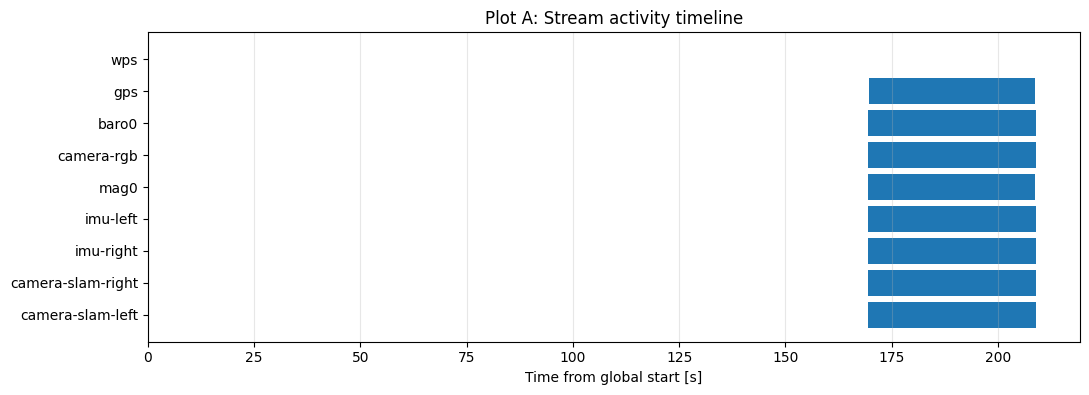

In [16]:
# plot A: timeline of stream activity based on t_min and t_max
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure temporal_df is available
if "temporal_df" not in globals():
    raise RuntimeError("temporal_df is not available.")

# Prepare data for timeline plot by filtering out streams without valid temporal bounds
plot_df = temporal_df.copy()
plot_df = plot_df[(plot_df["t_min_ns"].notna()) & (plot_df["t_max_ns"].notna())].reset_index(drop=True)

# If no valid temporal data is available, skip plotting
if len(plot_df) == 0:
    print("No valid temporal bounds available for timeline plot.")
else:
    t0 = plot_df["t_min_ns"].min() # global start time across all streams
    # Convert t_min and t_max to seconds relative to global start for plotting
    plot_df["start_s"] = (plot_df["t_min_ns"] - t0) / 1e9 
    plot_df["end_s"] = (plot_df["t_max_ns"] - t0) / 1e9
    plot_df["dur_s"] = plot_df["end_s"] - plot_df["start_s"]

    # Create a horizontal bar plot to visualize stream activity timelines
    fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(plot_df))))
    y = np.arange(len(plot_df))

    # Each bar starts at start_s and has a width of dur_s, positioned at the corresponding y index
    ax.barh(y, plot_df["dur_s"], left=plot_df["start_s"])
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["label"].fillna(plot_df["stream_id"]))
    ax.set_xlabel("Time from global start [s]")
    ax.set_title("Plot A: Stream activity timeline")
    ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

### **Note on Plot A: Stream activity timeline**

This plot shows the active time interval of each stream on a shared time axis (seconds from global start).  
In this recording, most streams appear aligned in the same acquisition window, which is a positive sign of temporal coherence across modalities.

The `wps` stream does not show a visible bar because its effective duration is null/very short (or not significant at this plot scale).  
This is not necessarily an error and is consistent with low-frequency or sparse-event streams.

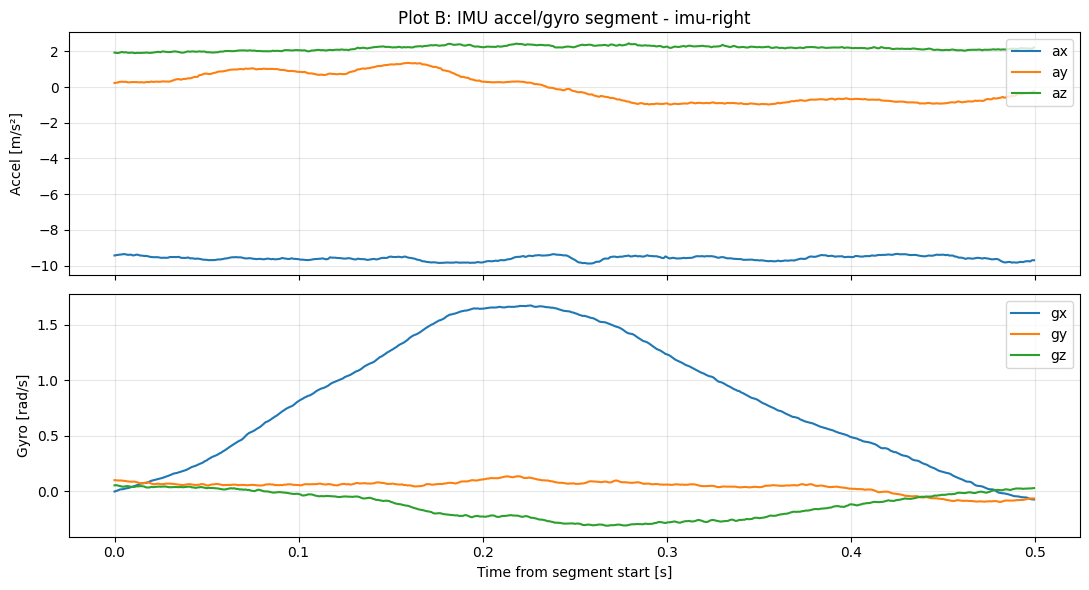

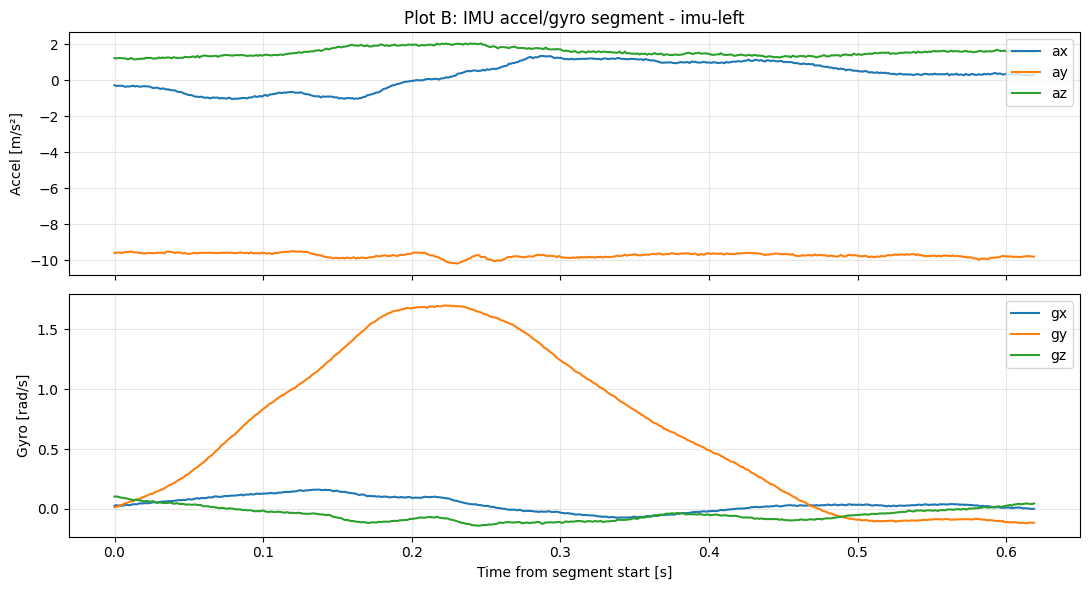

In [17]:
# plot B: IMU accel/gyro segment for each IMU stream
import numpy as np
import matplotlib.pyplot as plt
from projectaria_tools.core import sensor_data

# Ensure provider and streams_df are available
if "provider" not in globals() or provider is None:
    raise RuntimeError("provider is not available.")
if "streams_df" not in globals():
    raise RuntimeError("streams_df is not available.")

# Helper function to extract a 3D vector from an object using possible field names
def _vec3_from_obj(obj, names):
    for name in names:
        if hasattr(obj, name):
            v = getattr(obj, name)
            v = v() if callable(v) else v
            arr = np.asarray(v, dtype=float).reshape(-1)
            if arr.size >= 3:
                return arr[:3]
    return None

# Filter streams to find those related to IMU data based on label
imu_rows = streams_df[streams_df["label"].fillna("").str.lower().str.contains("imu")]

# For each IMU stream, attempt to read a segment of accel and gyro data, decode it, and plot it
if len(imu_rows) == 0:
    print("No IMU streams found.")
else:
    for _, r in imu_rows.iterrows():
        sid_str = r["stream_id"]
        label = r["label"]

        candidates = [s for s in provider.get_all_streams() if str(s) == sid_str]
        if not candidates:
            print(f"Skip {label}: stream_id not resolvable")
            continue
        
        # Assuming the first candidate is the correct stream_id for this row
        sid = candidates[0]
        n = int(provider.get_num_data(sid)) 
        N = min(500, n)
        if N == 0:
            print(f"Skip {label}: empty stream")
            continue
        
        # Read samples, decode accel and gyro data, and collect them for plotting
        t, acc, gyr = [], [], []
        for i in range(N):
            try:
                sample = provider.get_sensor_data_by_index(sid, i)
                t_ns = sample.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME)

                # Attempt to access IMU data using common field names
                imu = None
                if hasattr(sample, "imu_data"):
                    imu = sample.imu_data() if callable(sample.imu_data) else sample.imu_data
                elif hasattr(sample, "imu"):
                    imu = sample.imu() if callable(sample.imu) else sample.imu

                if imu is None:
                    continue
                
                # Try multiple possible field names for accel and gyro data to maximize compatibility
                a = _vec3_from_obj(imu, ["accel_msec2", "accel_m_s2", "accel"])
                g = _vec3_from_obj(imu, ["gyro_radsec", "gyro_rad_s", "gyro"])
                if a is None or g is None:
                    continue
                
                # Append the timestamp, accel, and gyro data for this sample to the lists for plotting
                t.append(t_ns)
                acc.append(a)
                gyr.append(g)
            except Exception:
                continue

        if len(t) == 0:
            print(f"Skip {label}: IMU decode not available with current bindings.")
            continue
        
        # Convert lists to numpy arrays for plotting
        t = np.asarray(t, dtype=np.int64)
        t_s = (t - t[0]) / 1e9
        acc = np.asarray(acc, dtype=float)
        gyr = np.asarray(gyr, dtype=float)

        # Create a two-panel plot to visualize accel and gyro data over time for this IMU stream
        fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

        axes[0].plot(t_s, acc[:, 0], label="ax")
        axes[0].plot(t_s, acc[:, 1], label="ay")
        axes[0].plot(t_s, acc[:, 2], label="az")
        axes[0].set_ylabel("Accel [m/s²]")
        axes[0].set_title(f"Plot B: IMU accel/gyro segment - {label}")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc="upper right")

        axes[1].plot(t_s, gyr[:, 0], label="gx")
        axes[1].plot(t_s, gyr[:, 1], label="gy")
        axes[1].plot(t_s, gyr[:, 2], label="gz")
        axes[1].set_xlabel("Time from segment start [s]")
        axes[1].set_ylabel("Gyro [rad/s]")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc="upper right")

        plt.tight_layout()
        plt.show()

### **Note on IMU field names and Plot B results**

It is possible to avoid relying only on “*common*” IMU field names.  
The exact names exposed by the current `projectaria_tools` bindings can be inspected at runtime (via `dir(sample)` / `dir(imu_obj)` on one decoded IMU sample), and then used explicitly in the plotting code rather than relying on fallback field names.

For this reason, the current fallback approach is acceptable for portability, but it can be replaced with exact field access once runtime introspection confirms the available attributes.

#### **Plot B analysis (imu-left, imu-right)**

- Both IMU streams show physically plausible accelerometer signals, with one axis close to gravity magnitude (~9.8 m/s²), while the dominant axis differs between left/right IMU due to sensor mounting and axis convention.
- Gyroscope plots show a clear transient rotation (peak around ~1.6–1.7 rad/s) on one dominant axis, with the other axes near zero.
- Curves are smooth, continuous, and without obvious spikes/dropouts in the shown segment.

Overall, these plots are consistent with valid IMU decoding and good short-window signal integrity.

## 1.8 Export Reports

In this section, we will export the main analysis artifacts produced in the notebook to make results reproducible and easy to reuse outside the notebook.

The export step will generate in the `data/processed/recording_test/` directory:

- `metadata_summary.json`: a compact run summary (input files, stream counts, status counts, and rate coverage).
- `stream_quality_report.csv`: a per-stream quality table combining discovery, temporal checks, rate validation, and integrity results.

These files provide a stable output for downstream checks, comparisons across recordings, and project documentation.

In [18]:
import os
import json
from datetime import datetime, timezone
import numpy as np
import pandas as pd

# Ensure required tables exist
required = ["streams_df", "temporal_df", "rate_df", "integrity_df"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects before export: {missing}")

# Output directory
OUT_DIR = os.path.join("..", "data", "processed", "recording_test")
os.makedirs(OUT_DIR, exist_ok=True)

# Define output paths for summary JSON and quality CSV
SUMMARY_JSON_PATH = os.path.join(OUT_DIR, "metadata_summary.json")
QUALITY_CSV_PATH = os.path.join(OUT_DIR, "stream_quality_report.csv")

# Build stream quality report (one row per stream)
quality_df = streams_df.copy()

# Merge temporal consistency results
temporal_cols = [
    "stream_id", "label", "sample_count", "t_min_ns", "t_max_ns", "duration_s",
    "delta_min_ms", "delta_median_ms", "delta_max_ms", "status"
]

# Merge rate validation results
rate_cols = [
    "stream_id", "label", "measured_rate_hz", "nominal_rate_hz",
    "abs_error_hz", "rel_error_pct"
]

# Merge integrity check results
integrity_cols = [
    "stream_id", "label", "tested_indices", "read_ok", "read_fail",
    "status", "error_example"
]

# Merge all quality-related tables into a single DataFrame for export
quality_df = quality_df.merge(
    temporal_df[temporal_cols].rename(
        columns={"sample_count": "temporal_sample_count", "status": "temporal_status"}
    ),
    on=["stream_id", "label"],
    how="left",
)

# Merge rate validation results
quality_df = quality_df.merge(
    rate_df[rate_cols],
    on=["stream_id", "label"],
    how="left",
)

# Merge integrity check results, 
quality_df = quality_df.merge(
    integrity_df[integrity_cols].rename(
        columns={"status": "integrity_status"}
    ),
    on=["stream_id", "label"],
    how="left",
)

# Normalize NaN -> None-like for CSV readability and JSON compatibility
quality_df = quality_df.replace({np.nan: None})

# Save CSV
quality_df.to_csv(QUALITY_CSV_PATH, index=False, encoding="utf-8")

In [19]:
# Build compact metadata summary JSON
summary = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "input_files": {
        "vrs_path": VRS_PATH if "VRS_PATH" in globals() else None,
        "json_path": JSON_PATH if "JSON_PATH" in globals() else None,
    },
    "counts": {
        "num_streams": int(len(streams_df)),
        "num_modalities": int(streams_df["modality"].nunique()) if "modality" in streams_df.columns else None,
    },
    "temporal_status_counts": temporal_df["status"].value_counts(dropna=False).to_dict() if "status" in temporal_df.columns else {},
    "integrity_status_counts": integrity_df["status"].value_counts(dropna=False).to_dict() if "status" in integrity_df.columns else {},
    "rate_coverage": {
        "with_measured_rate": int(pd.notna(rate_df["measured_rate_hz"]).sum()) if "measured_rate_hz" in rate_df.columns else 0,
        "with_nominal_rate": int(pd.notna(rate_df["nominal_rate_hz"]).sum()) if "nominal_rate_hz" in rate_df.columns else 0,
    },
    "artifacts": {
        "metadata_summary_json": SUMMARY_JSON_PATH,
        "stream_quality_report_csv": QUALITY_CSV_PATH,
    },
}

with open(SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Export completed.")
print("JSON:", os.path.abspath(SUMMARY_JSON_PATH))
print("CSV :", os.path.abspath(QUALITY_CSV_PATH))

display(quality_df.head(10))


Export completed.
JSON: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\processed\recording_test\metadata_summary.json
CSV : c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\processed\recording_test\stream_quality_report.csv


,stream_id,label,modality,sample_count,temporal_sample_count,t_min_ns,t_max_ns,duration_s,delta_min_ms,delta_median_ms,...,temporal_status,measured_rate_hz,nominal_rate_hz,abs_error_hz,rel_error_pct,tested_indices,read_ok,read_fail,integrity_status,error_example
0,1201-1,camera-slam-left,image,1185,1185,169385598075.0,208845950075.0,39.460352,33.328,33.328,...,OK,30.004801,30.0,0.004801,0.016003,"[0, 592, 1184]",3,0,OK,None
1,1201-2,camera-slam-right,image,1185,1185,169385598075.0,208845950075.0,39.460352,33.327988,33.328,...,OK,30.004801,30.0,0.004801,0.016003,"[0, 592, 1184]",3,0,OK,None
2,214-1,camera-rgb,image,1185,1185,169385504600.0,208845858475.0,39.460354,30.8287,33.3281,...,OK,30.004711,30.0,0.004711,0.015702,"[0, 592, 1184]",3,0,OK,None
3,1202-1,imu-right,imu,39454,39454,169368945650.0,208860276400.0,39.491331,0.923425,1.000975,...,OK,999.02595,1000.0,0.97405,0.097405,"[0, 19727, 39453]",3,0,OK,None
4,1202-2,imu-left,imu,31845,31845,169369106212.0,208859868400.0,39.490762,1.239975,1.240137,...,OK,806.362523,800.0,6.362523,0.795315,"[0, 15922, 31844]",3,0,OK,None
5,1203-1,mag0,other-sensor,394,394,169437253550.0,208808832062.0,39.371579,100.130087,100.178788,...,OK,9.982153,None,None,None,"[0, 197, 393]",3,0,OK,None
6,247-1,baro0,other-sensor,1966,1966,169362913162.0,208858007475.0,39.495094,20.060737,20.093125,...,OK,49.768267,50.0,0.231733,0.463467,"[0, 983, 1965]",3,0,OK,None
7,281-1,gps,other-sensor,40,40,169633060715.0,208632695961.0,38.999635,998.862552,1000.038594,...,OK,0.999961,1.0,0.000039,0.003859,"[0, 20, 39]",3,0,OK,None
8,282-1,wps,unknown,69,69,-1.0,-1.0,0.0,None,None,...,OK,None,None,None,None,"[0, 34, 68]",3,0,OK,None
9,283-1,bluetooth,unknown,0,0,None,None,0.0,None,None,...,OK,None,None,None,None,[],0,0,EMPTY,None


### **Note on export results**

The main outcomes of the export are:

- All discovered streams were processed (`num_streams = 10`).
- Temporal checks returned `OK` for all streams.
- Integrity checks returned `OK` for 9 streams and `EMPTY` for `bluetooth` (expected because no samples were recorded).
- Measured vs nominal rate comparison is available where nominal metadata exists (IMU, barometer, GPS), with low relative errors.

Additional note:
- The `wps` stream reports `t_min_ns = -1` and `t_max_ns = -1`, which should be treated as non-valid/sentinel timestamps for this recording.

# Final Conclusion

This notebook completed the full metadata inspection workflow for `recording_test.vrs` and `recording_test.json`. The pipeline:
- initialized and validated the VRS data provider and JSON parsing,
- discovered and categorized all available streams,
- computed per-stream temporal bounds and consistency metrics,
- compared measured vs nominal rates where metadata was available,
- executed basic integrity checks (first/middle/last sample reads),
- generated exploratory plots (shared stream timeline + IMU accel/gyro segments),
- exported reproducible artifacts:
  - `metadata_summary.json`
  - `stream_quality_report.csv`.

Overall, results are consistent and technically sound: streams were processed successfully, diagnostics are explicit, and exported outputs are ready for downstream analysis and documentation.